# Tilt Census

Counts and distributions of tilt distance and direction by eddy type and region.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)

region_group_map = {"S1": "Shelf", "S2": "Shelf", "U1": "Upstream", "U2": "Upstream", "D1": "Downstream", "D2": "Downstream"}
df_eddies["RegionGroup"] = df_eddies.Region.map(region_group_map)
df_eddies.head()


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region,RegionGroup
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2,Upstream
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2,Upstream
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2,Upstream
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976810,184.917206,U2,Upstream
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.067059,181.174121,U2,Upstream


In [2]:
census = (
    df_eddies
    .groupby(["Cyc", "RegionGroup"], dropna=False)
    .agg(eddy_days=("Eddy", "size"), unique_eddies=("Eddy", "nunique"), tilt_days=("TiltDis", "count"), median_tilt=("TiltDis", "median"), mean_dir=("TiltDir", tilt.circular_mean_deg_true_north))
    .reset_index()
)
census


,Cyc,RegionGroup,eddy_days,unique_eddies,tilt_days,median_tilt,mean_dir
0,AE,Downstream,35659,859,30278,15.838327,8.312842
1,AE,Shelf,8985,404,7196,17.303306,344.906654
2,AE,Upstream,19187,574,15719,29.884091,26.371253
3,CE,Downstream,26096,779,21870,12.956538,145.123646
4,CE,Shelf,13248,542,10771,11.894466,265.410702
5,CE,Upstream,22051,597,18625,23.607385,143.928342


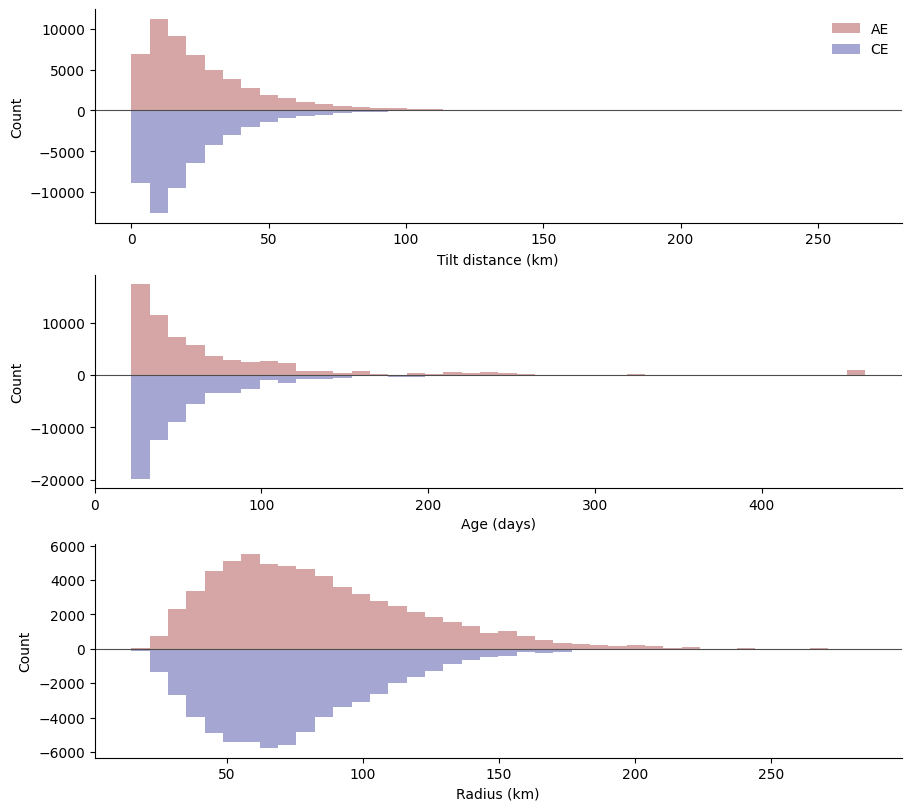

In [3]:
fig, axs = plt.subplots(3, 1, figsize=(9, 8), constrained_layout=True)
metrics = [("TiltDis", "Tilt distance (km)"), ("Age", "Age (days)"), ("Rc", "Radius (km)")]
for ax, (col, xlabel) in zip(axs, metrics):
    ae = df_eddies.loc[df_eddies.Cyc == "AE", col].dropna()
    ce = df_eddies.loc[df_eddies.Cyc == "CE", col].dropna()
    bins = tilt.shared_bins(ae, ce)
    tilt.mirrored_hist(ax, ae, ce, bins, xlabel)
axs[0].legend(frameon=False)
plt.show()


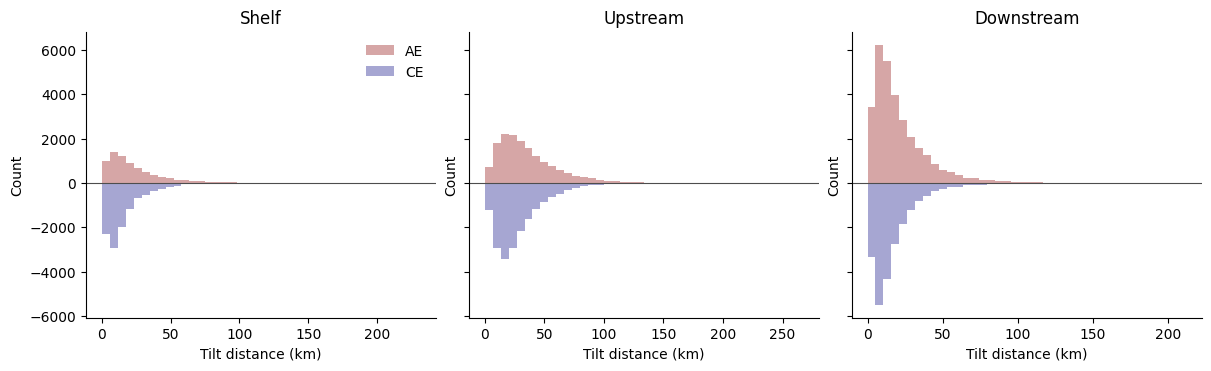

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, constrained_layout=True)
for ax, region in zip(axs, ["Shelf", "Upstream", "Downstream"]):
    subset = df_eddies.loc[df_eddies.RegionGroup == region]
    ae = subset.loc[subset.Cyc == "AE", "TiltDis"].dropna()
    ce = subset.loc[subset.Cyc == "CE", "TiltDis"].dropna()
    bins = tilt.shared_bins(ae, ce)
    tilt.mirrored_hist(ax, ae, ce, bins, "Tilt distance (km)")
    ax.set_title(region)
axs[0].legend(frameon=False)
plt.show()
